# AnalystLab Africa — Week 1 Case Study
## Customer Churn Analysis for ABC Communications Ltd
**Analyst:** Peter Thuo Muiruri

---
# Data Loading & Inspection

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display and plotting defaults
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

FILE_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.xlsx'
df = pd.read_excel(FILE_PATH)
df.shape

(7043, 21)

### Rows, columns, and data types

In [5]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.dtypes

Rows: 7043, Columns: 21


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Missing values

In [7]:
# Standard null check first
print("Standard nulls per column:")
print(df.isnull().sum())

# TotalCharges hides blanks as empty strings, not NaN, so isnull() misses them
blank_total_charges = df[df['TotalCharges'].astype(str).str.strip() == '']
print(f"\nRows with blank TotalCharges (hidden missing values): {len(blank_total_charges)}")
blank_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Standard nulls per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Rows with blank TotalCharges (hidden missing values): 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [8]:
# Convert TotalCharges to numeric, coercing blanks to NaN, then fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm the fix
print(f"Remaining nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Data type now: {df['TotalCharges'].dtype}")

Remaining nulls in TotalCharges: 0
Data type now: float64


### Duplicate records

In [9]:
dupes = df.duplicated().sum()
dupes_by_id = df.duplicated(subset='customerID').sum()
print(f"Fully duplicated rows: {dupes}")
print(f"Duplicate customerIDs: {dupes_by_id}")

Fully duplicated rows: 0
Duplicate customerIDs: 0


### Summary statistics

In [10]:
df.describe(include='number')

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


### Churn column and target encoding

In [12]:
df['Churn'].value_counts()


No     5174
Yes    1869
Name: Churn, dtype: int64

In [13]:
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

# numeric flag used later for correlation heatmap
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

Overall churn rate: 26.54%



# Business Data Analysis

## Business Question 1: What does the customer base look like?

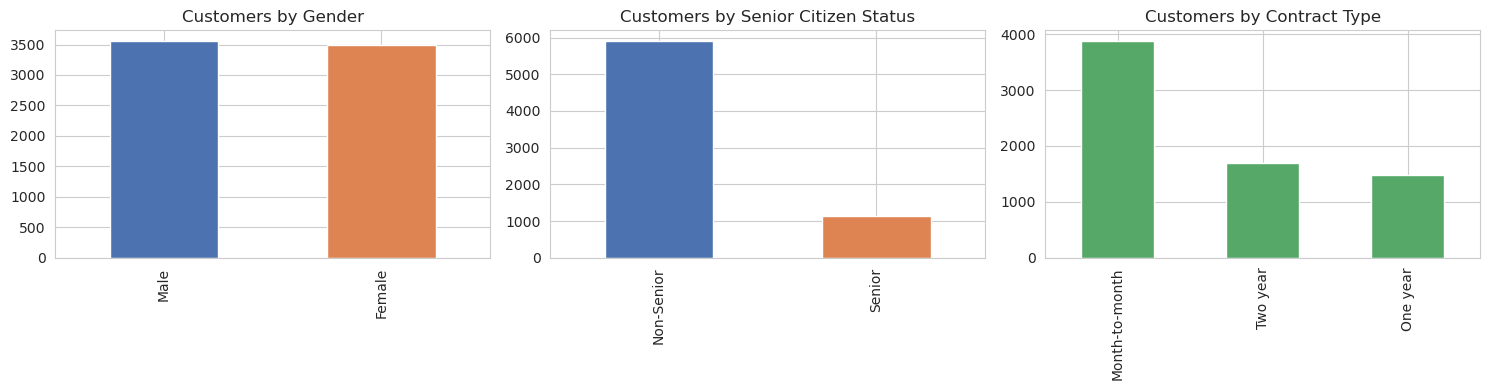

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['gender'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Customers by Gender')
axes[0].set_xlabel('')

df['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'}).value_counts().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Customers by Senior Citizen Status')
axes[1].set_xlabel('')

df['Contract'].value_counts().plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Customers by Contract Type')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

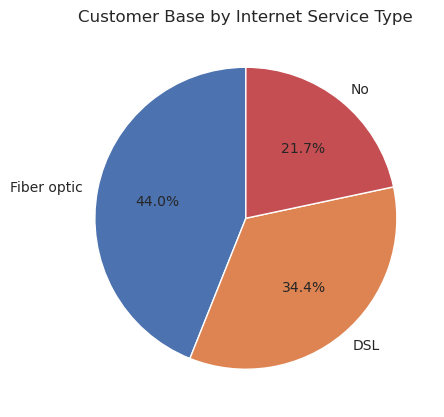

In [15]:
plt.figure(figsize=(6, 5))
df['InternetService'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90,
    colors=['#4C72B0', '#DD8452', '#C44E52']
)
plt.title('Customer Base by Internet Service Type')
plt.ylabel('')
plt.show()

## Business Question 2: Which segments have the highest churn?

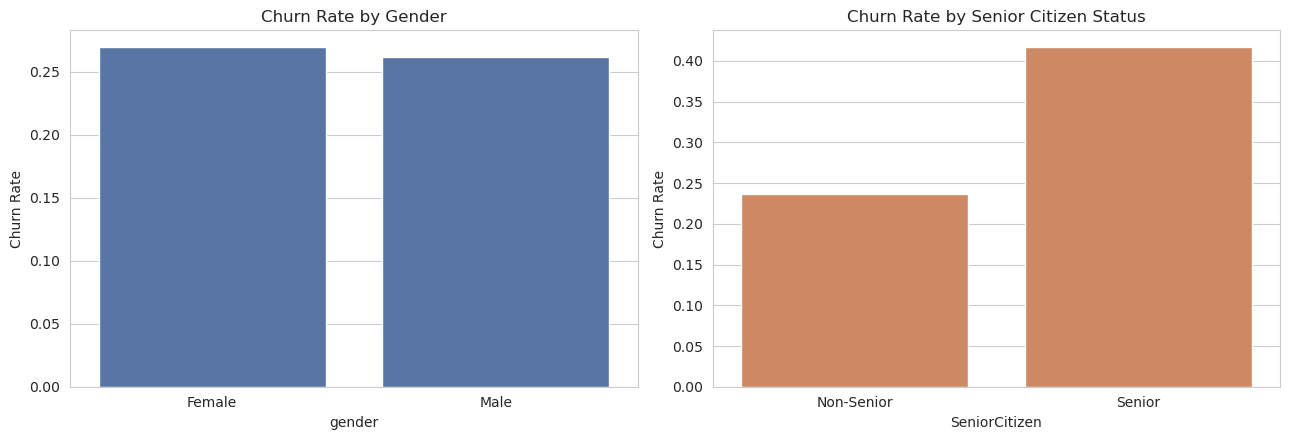

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=df, x='gender', y='ChurnFlag', ax=axes[0], estimator=np.mean, ci=None, color='#4C72B0')
axes[0].set_title('Churn Rate by Gender')
axes[0].set_ylabel('Churn Rate')

sns.barplot(data=df, x='SeniorCitizen', y='ChurnFlag', ax=axes[1], estimator=np.mean, ci=None, color='#DD8452')
axes[1].set_xticklabels(['Non-Senior', 'Senior'])
axes[1].set_title('Churn Rate by Senior Citizen Status')
axes[1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

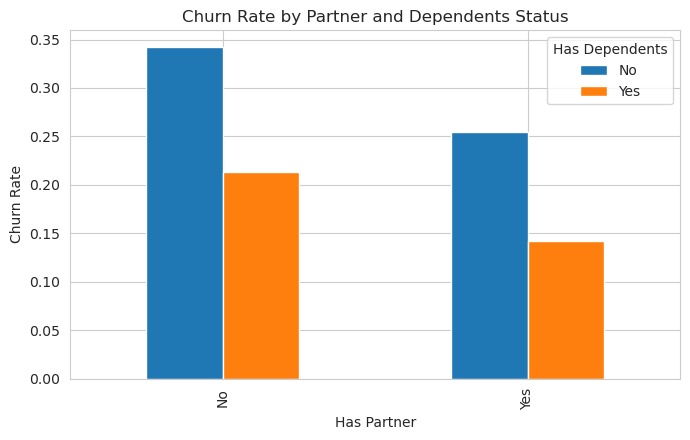

In [24]:
plt.figure(figsize=(7, 4.5))
partner_dep = df.groupby(['Partner', 'Dependents'])['ChurnFlag'].mean().unstack()
partner_dep.plot(kind='bar', ax=plt.gca())
plt.title('Churn Rate by Partner and Dependents Status')
plt.ylabel('Churn Rate')
plt.xlabel('Has Partner')
plt.legend(title='Has Dependents')
plt.tight_layout()
plt.show()

## Business Question 3: Does contract type influence retention?

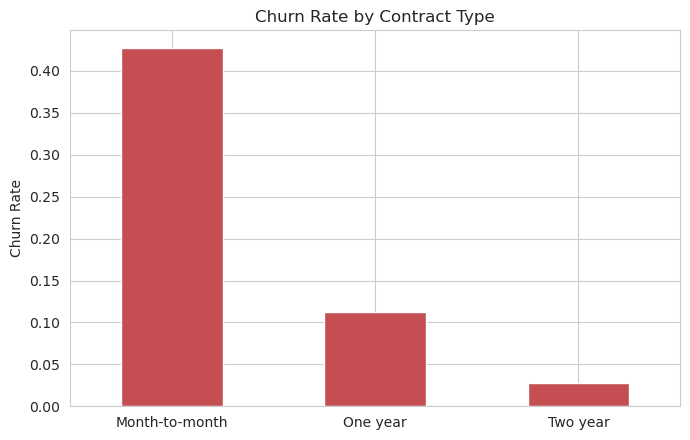

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: ChurnFlag, dtype: float64

In [27]:
plt.figure(figsize=(7, 4.5))
contract_churn = df.groupby('Contract')['ChurnFlag'].mean().sort_values(ascending=False)
contract_churn.plot(kind='bar', color='#C44E52')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
contract_churn

## Business Question 4: Does tenure affect loyalty?

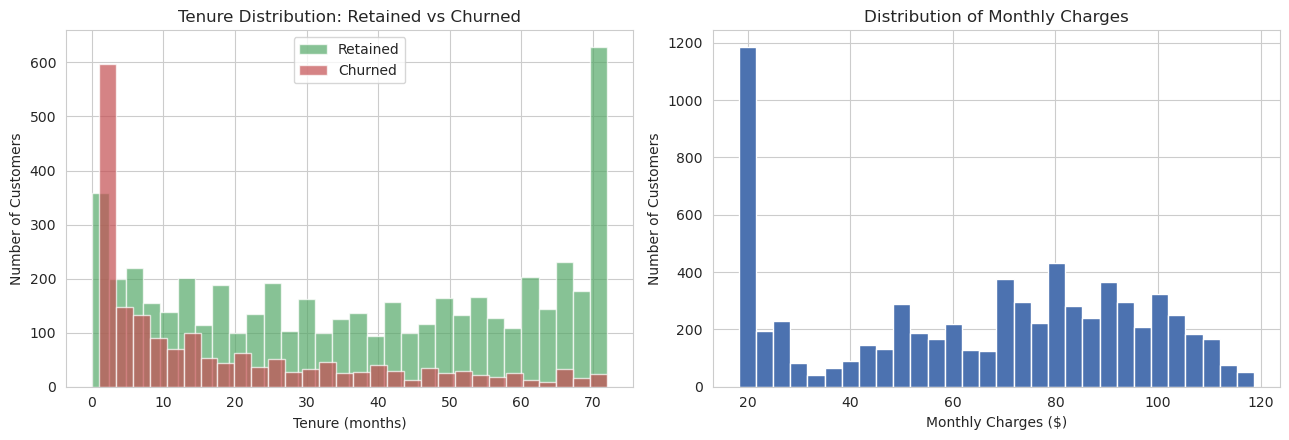

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df[df['Churn'] == 'No']['tenure'], bins=30, alpha=0.7, label='Retained', color='#55A868')
axes[0].hist(df[df['Churn'] == 'Yes']['tenure'], bins=30, alpha=0.7, label='Churned', color='#C44E52')
axes[0].set_title('Tenure Distribution: Retained vs Churned')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

axes[1].hist(df['MonthlyCharges'], bins=30, color='#4C72B0')
axes[1].set_title('Distribution of Monthly Charges')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

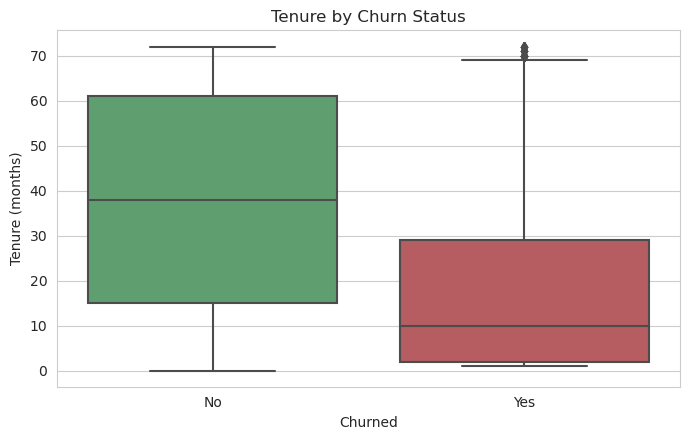

In [19]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x='Churn', y='tenure', palette=['#55A868', '#C44E52'])
plt.title('Tenure by Churn Status')
plt.xlabel('Churned')
plt.ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

## Business Question 5: Which services influence churn?

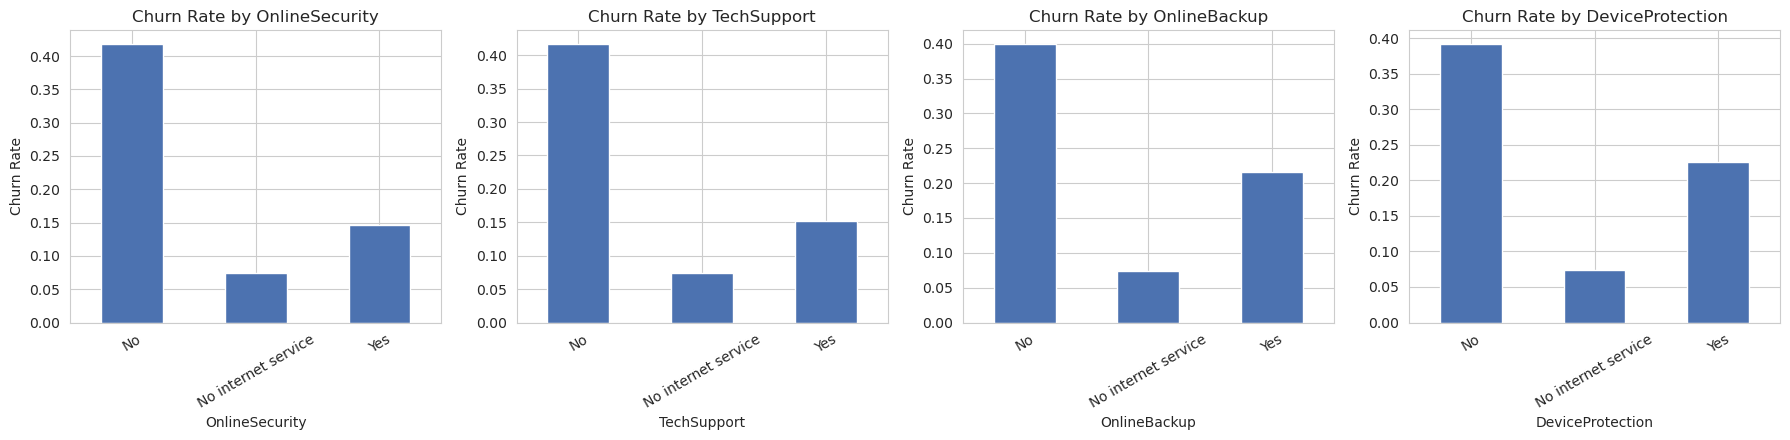

In [20]:
service_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, col in zip(axes, service_cols):
    rates = df.groupby(col)['ChurnFlag'].mean()
    rates.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

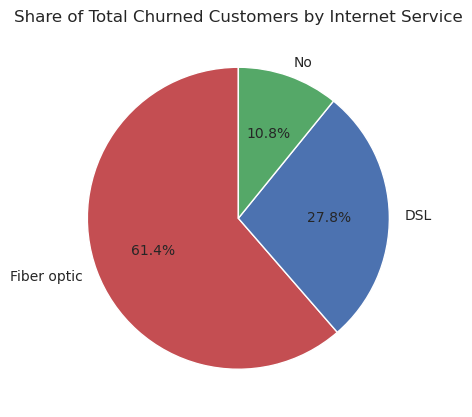

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: ChurnFlag, dtype: float64

In [21]:
plt.figure(figsize=(6, 5))
df['InternetService'].value_counts()

internet_churn = df.groupby('InternetService')['ChurnFlag'].mean().sort_values(ascending=False)
internet_churn.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#C44E52', '#4C72B0', '#55A868'])
plt.title('Share of Total Churned Customers by Internet Service')
plt.ylabel('')
plt.show()
internet_churn

## Business Question 6: Which payment methods have higher churn?

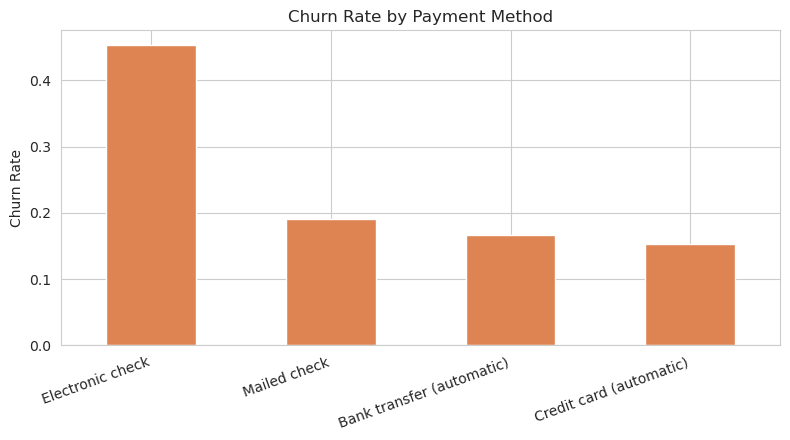

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: ChurnFlag, dtype: float64

In [22]:
plt.figure(figsize=(8, 4.5))
payment_churn = df.groupby('PaymentMethod')['ChurnFlag'].mean().sort_values(ascending=False)
payment_churn.plot(kind='bar', color='#DD8452')
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
payment_churn

## Correlation Overview (supports all business questions)

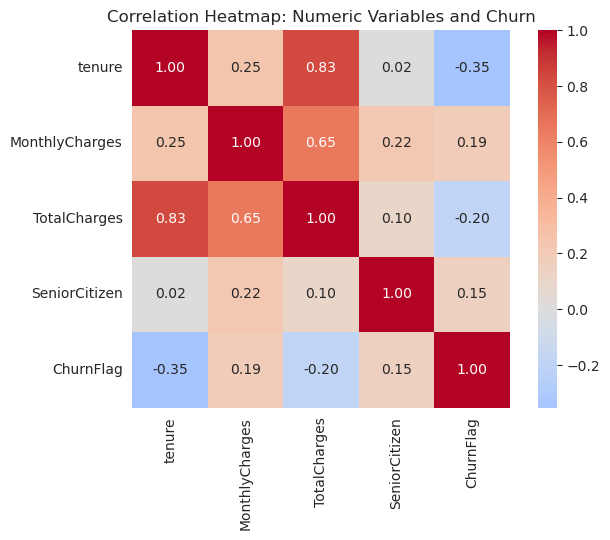

In [23]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'ChurnFlag']]
corr = numeric_df.corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap: Numeric Variables and Churn')
plt.tight_layout()
plt.show()